# **Pós-Graduação: Ciência de Dados e Inteligência Artificial.**
## **AED - Análise Estatística de Dados**
---
## **Gustavo Calin dos Santos 17.01190-6**


---

**Atividade 2 - Análise Estatística**

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_1samp, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.weightstats import ztest
import numpy as np

## 1) Aquisição de dados:
## 2) Importação

In [2]:
# Importação de dados
df = pd.read_csv('/content/Crash_Data.csv')
print(f'Dimensionalidade do dataset: {df.shape}')
# Exibe o início do dataset
df.head()

Dimensionalidade do dataset: (52843, 23)


<ipython-input-2-444cf83ad67b>:2: DtypeWarning: Columns (10,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Crash_Data.csv')


,Crash ID,State,Month,Year,Dayweek,Time,Crash Type,Bus Involvement,Heavy Rigid Truck Involvement,Articulated Truck Involvement,...,Age,National Remoteness Areas,SA4 Name 2016,National LGA Name 2017,National Road Type,Christmas Period,Easter Period,Age Group,Day of week,Time of day
0,20212133,Vic,9,2021,Sunday,0:30,Single,NaN,NaN,NaN,...,38,Inner Regional Australia,Melbourne - Outer East,Yarra Ranges (S),Arterial Road,No,No,26_to_39,Weekend,Night
1,20214022,SA,9,2021,Saturday,23:31,Multiple,No,No,No,...,28,Major Cities of Australia,Adelaide - North,Playford (C),NaN,No,No,26_to_39,Weekend,Night
2,20212096,Vic,9,2021,Saturday,23:00,Single,NaN,NaN,NaN,...,19,Inner Regional Australia,Hume,Wangaratta (RC),Access road,No,No,17_to_25,Weekend,Night
3,20212145,Vic,9,2021,Saturday,22:25,Single,NaN,NaN,NaN,...,23,Outer Regional Australia,Hume,Wangaratta (RC),Arterial Road,No,No,17_to_25,Weekend,Night
4,20212075,Vic,9,2021,Saturday,5:15,Single,NaN,NaN,NaN,...,46,Major Cities of Australia,Melbourne - South East,Casey (C),Local Road,No,No,40_to_64,Weekend,Night


## 3) Tratamento de dados

In [3]:
# Selecionar colunas par atrabalher
df.columns

Index(['Crash ID', 'State', 'Month', 'Year', 'Dayweek', 'Time', 'Crash Type',
       'Bus Involvement', 'Heavy Rigid Truck Involvement',
       'Articulated Truck Involvement', 'Speed Limit', 'Road User', 'Gender',
       'Age', 'National Remoteness Areas', 'SA4 Name 2016',
       'National LGA Name 2017', 'National Road Type', 'Christmas Period',
       'Easter Period', 'Age Group', 'Day of week', 'Time of day'],
      dtype='object')

In [4]:
# Dimensão do conjunto de dados
print('Dimensão do dataset', df.shape)

Dimensão do dataset (52843, 23)


In [5]:
# Valores únicos
for col in df.columns:
  print(col, ':', df[col].unique())

Crash ID : [20212133 20214022 20212096 ... 19891246 19895088 19896063]
State : ['Vic' 'SA' 'Qld' 'WA' 'NSW' 'NT' 'ACT' 'Tas']
Month : [ 9  8  7  6  5  4  3  2  1 12 11 10]
Year : [2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010 2009 2008
 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996 1995 1994
 1993 1992 1991 1990 1989]
Dayweek : ['Sunday' 'Saturday' 'Thursday' 'Wednesday' 'Friday' 'Tuesday' 'Monday']
Time : ['0:30' '23:31' '23:00' ... '3:42' '22:33' '6:57']
Crash Type : ['Single' 'Multiple']
Bus Involvement : [nan 'No' 'Yes']
Heavy Rigid Truck Involvement : [nan 'No' 'Yes']
Articulated Truck Involvement : [nan 'No' 'Yes']
Speed Limit : [nan '110' '100' '60' '80' '50' '70' '90' '40' '130' '20' '10' '30' '25'
 '15' '<40' '5' 'Unspecified' '75' 110 100 60 -9 80 90 70 40 50 30 20 75]
Road User : ['Motorcycle rider' 'Pedestrian' 'Passenger' 'Driver' 'Other/-9'
 'Pedal cyclist' 'Motorcycle pillion passenger']
Gender : ['Male' 'Female' nan 'Unspecified']
Age : [ 38 

In [6]:
# Renomeando Colunas
df.columns = ['ID', 'Estado', 'Mes', 'Ano', 'Dia da Semana', 'Hora', 'Tipo de Acidente', 'Envolvimento Onibus', 'Envolvimento de Caminhao Pesado', 'Envolvimento de Caminhao Articulado',
              'Limite de Velocidade', 'Usuario de Rodovia', 'Genero', 'Idade', 'Area Remota Nacional', 'Nome SA4 2016', 'Nome LGA 2017', 'Tipo de Rodovia Nacional', 'Periodo de Natal',
              'Periodo de Pascoa', 'Grupo Etario', 'Periodo da Semana', 'Hora do Dia']

In [7]:
# Verificar valores ausentes
df.isnull().sum()

,0
ID,0
Estado,0
Mes,0
Ano,0
Dia da Semana,0
Hora,40
Tipo de Acidente,0
Envolvimento Onibus,22
Envolvimento de Caminhao Pesado,20515
Envolvimento de Caminhao Articulado,22


## Remover colunas National Remoteness Areas, SA4 Name 2016, National LGA Name 2017, National Road Type por conter muitos dados nulos

In [8]:
df = df.drop(['Area Remota Nacional', 'Nome SA4 2016', 'Nome LGA 2017', 'Tipo de Rodovia Nacional', 'Envolvimento de Caminhao Pesado'], axis=1)
df.head()

,ID,Estado,Mes,Ano,Dia da Semana,Hora,Tipo de Acidente,Envolvimento Onibus,Envolvimento de Caminhao Articulado,Limite de Velocidade,Usuario de Rodovia,Genero,Idade,Periodo de Natal,Periodo de Pascoa,Grupo Etario,Periodo da Semana,Hora do Dia
0,20212133,Vic,9,2021,Sunday,0:30,Single,NaN,NaN,NaN,Motorcycle rider,Male,38,No,No,26_to_39,Weekend,Night
1,20214022,SA,9,2021,Saturday,23:31,Multiple,No,No,110,Pedestrian,Female,28,No,No,26_to_39,Weekend,Night
2,20212096,Vic,9,2021,Saturday,23:00,Single,NaN,NaN,NaN,Passenger,Male,19,No,No,17_to_25,Weekend,Night
3,20212145,Vic,9,2021,Saturday,22:25,Single,NaN,NaN,NaN,Driver,Male,23,No,No,17_to_25,Weekend,Night
4,20212075,Vic,9,2021,Saturday,5:15,Single,NaN,NaN,NaN,Motorcycle rider,Male,46,No,No,40_to_64,Weekend,Night


### Removidas as linha nulas, visto que não seriam um grande número de linhas removidas, assim não atrapalhando a analise

In [9]:
#remover linhas nulas
df = df.dropna()

In [10]:
df.shape

(51997, 18)

### Subistituindo linhas

In [11]:
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Saturday', 'Sabado')
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Thursday', 'Quinta-feira')
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Sunday', 'Domingo')
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Friday', 'Sexta-feira')
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Tuesday', 'Terca-feira')
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Wednesday', 'Quarta-feira')
df['Dia da Semana'] = df['Dia da Semana'].str.replace('Monday', 'Segunda-feira')

In [12]:
df['Tipo de Acidente'] = df['Tipo de Acidente'].str.replace('Multiple', 'Multiplo')
df['Tipo de Acidente'] = df['Tipo de Acidente'].str.replace('Single', 'Unico')

In [13]:
df['Envolvimento Onibus'] = df['Envolvimento Onibus'].str.replace('No', 'Não')
df['Envolvimento Onibus'] = df['Envolvimento Onibus'].str.replace('Yes', 'Sim')

In [14]:
df['Envolvimento de Caminhao Articulados'] = df['Envolvimento de Caminhao Articulado'].str.replace('No', 'Não')
df['Envolvimento de Caminhao Articulado'] = df['Envolvimento de Caminhao Articulado'].str.replace('Yes', 'Sim')

In [15]:
df['Usuario de Rodovia'] = df['Usuario de Rodovia'].str.replace('Pedestrian', 'Pedestre')
df['Usuario de Rodovia'] = df['Usuario de Rodovia'].str.replace('Motorcycle rider', 'Motociclista')
df['Usuario de Rodovia'] = df['Usuario de Rodovia'].str.replace('Driver', 'Motorista')
df['Usuario de Rodovia'] = df['Usuario de Rodovia'].str.replace('Passenger', 'Passageiro')
df['Usuario de Rodovia'] = df['Usuario de Rodovia'].str.replace('Motorcycle pillion passenger', 'Garupa')
df['Usuario de Rodovia'] = df['Usuario de Rodovia'].str.replace('Pedal cyclist', 'Ciclista')

In [16]:
df['Genero'] = df['Genero'].str.replace('Female', 'Feminino')
df['Genero'] = df['Genero'].str.replace('Male', 'Masculino')
df['Genero'] = df['Genero'].str.replace('Unspecified', 'Não Especificado')

In [17]:
# remover genero Unspecified
df = df[df['Genero'] != 'Não Especificado']

In [18]:
df['Periodo de Natal'] = df['Periodo de Natal'].str.replace('No', 'Não')
df['Periodo de Natal'] = df['Periodo de Natal'].str.replace('Yes', 'Sim')

In [19]:
df['Periodo de Pascoa'] = df['Periodo de Pascoa'].str.replace('No', 'Não')
df['Periodo de Pascoa'] = df['Periodo de Pascoa'].str.replace('Yes', 'Sim')

In [20]:
df['Periodo da Semana'] = df['Periodo da Semana'].str.replace('Weekend', 'Fim de Semana')
df['Periodo da Semana'] = df['Periodo da Semana'].str.replace('Weekday', 'Dia de Semana')

In [21]:
df['Hora do Dia'] = df['Hora do Dia'].str.replace('Night', 'Noite')
df['Hora do Dia'] = df['Hora do Dia'].str.replace('Day', 'Dia')

In [22]:
df['Grupo Etario'] = df['Grupo Etario'].str.replace('26_to_39', '15 a 24')
df['Grupo Etario'] = df['Grupo Etario'].str.replace('17_to_25', '17 a 25')
df['Grupo Etario'] = df['Grupo Etario'].str.replace('40_to_64', '40 a 64')
df['Grupo Etario'] = df['Grupo Etario'].str.replace('0_to_16', '0 a 16')
df['Grupo Etario'] = df['Grupo Etario'].str.replace('65_to_74', '65 a 74')
df['Grupo Etario'] = df['Grupo Etario'].str.replace('75_or_older', '75+')

In [23]:
df.head()

,ID,Estado,Mes,Ano,Dia da Semana,Hora,Tipo de Acidente,Envolvimento Onibus,Envolvimento de Caminhao Articulado,Limite de Velocidade,Usuario de Rodovia,Genero,Idade,Periodo de Natal,Periodo de Pascoa,Grupo Etario,Periodo da Semana,Hora do Dia,Envolvimento de Caminhao Articulados
1,20214022,SA,9,2021,Sabado,23:31,Multiplo,Não,No,110,Pedestre,Feminino,28,Não,Não,15 a 24,Fim de Semana,Noite,Não
5,20213034,Qld,9,2021,Sabado,4:00,Multiplo,Não,No,100,Motociclista,Masculino,19,Não,Não,17 a 25,Fim de Semana,Noite,Não
6,20215071,WA,9,2021,Sabado,19:10,Unico,Não,No,100,Motorista,Feminino,20,Não,Não,17 a 25,Fim de Semana,Noite,Não
9,20213092,Qld,9,2021,Sabado,2:00,Unico,Não,No,60,Motorista,Masculino,47,Não,Não,40 a 64,Fim de Semana,Noite,Não
10,20214053,SA,9,2021,Quinta-feira,21:00,Unico,Não,No,80,Motorista,Masculino,24,Não,Não,17 a 25,Dia de Semana,Noite,Não


### Analise exploratoria de dados

In [24]:
shape = df.shape

# Valores nulos por coluna
missing_values = df.isnull().sum().sort_values(ascending=False)

# Estatísticas descritivas para variáveis numéricas
numeric_description = df.describe()

# Principais categorias para variáveis categóricas
categorical_columns = df.select_dtypes(include=['object']).columns
top_categories = {col: df[col].value_counts().head(5) for col in categorical_columns}

shape, missing_values, numeric_description, top_categories

((51996, 19),
 ID                                      0
 Estado                                  0
 Mes                                     0
 Ano                                     0
 Dia da Semana                           0
 Hora                                    0
 Tipo de Acidente                        0
 Envolvimento Onibus                     0
 Envolvimento de Caminhao Articulado     0
 Limite de Velocidade                    0
 Usuario de Rodovia                      0
 Genero                                  0
 Idade                                   0
 Periodo de Natal                        0
 Periodo de Pascoa                       0
 Grupo Etario                            0
 Periodo da Semana                       0
 Hora do Dia                             0
 Envolvimento de Caminhao Articulados    0
 dtype: int64,
                  ID           Mes           Ano         Idade
 count  5.199600e+04  51996.000000  51996.000000  51996.000000
 mean   2.002986e+07      6.

In [25]:
df.shape

(51996, 19)

In [26]:
df.describe()

,ID,Mes,Ano,Idade
count,5.199600e+04,51996.000000,51996.000000,51996.000000
mean,2.002986e+07,6.552581,2002.699304,39.788080
std,9.413532e+04,3.456596,9.408908,21.732116
min,1.989100e+07,1.000000,1989.000000,0.000000
25%,1.994605e+07,4.000000,1994.000000,22.000000
50%,2.002135e+07,7.000000,2002.000000,34.000000
75%,2.010502e+07,10.000000,2010.000000,55.000000
max,2.021801e+07,12.000000,2021.000000,101.000000


In [27]:
colunas_categoricas = df.select_dtypes(include=['object']).columns
top_categorias = {col: df[col].value_counts().head(5) for col in colunas_categoricas}
top_categorias

{'Estado': Estado
 NSW    16234
 Vic    11380
 Qld    10468
 WA      6137
 SA      4539
 Name: count, dtype: int64,
 'Dia da Semana': Dia da Semana
 Sabado          9527
 Sexta-feira     8525
 Domingo         8332
 Quinta-feira    6988
 Quarta-feira    6555
 Name: count, dtype: int64,
 'Hora': Hora
 15:00    1131
 16:00    1040
 18:00     972
 17:00     946
 14:00     939
 Name: count, dtype: int64,
 'Tipo de Acidente': Tipo de Acidente
 Unico       28660
 Multiplo    23336
 Name: count, dtype: int64,
 'Envolvimento Onibus': Envolvimento Onibus
 Não    51028
 Sim      968
 Name: count, dtype: int64,
 'Envolvimento de Caminhao Articulado': Envolvimento de Caminhao Articulado
 No     46703
 Sim     5293
 Name: count, dtype: int64,
 'Limite de Velocidade': Limite de Velocidade
 100    10988
 100     7198
 60      7107
 60      6550
 80      4434
 Name: count, dtype: int64,
 'Usuario de Rodovia': Usuario de Rodovia
 Motorista       23505
 Passageiro      11987
 Pedestre         8114
 Motoc

In [28]:
# Faixa etaria que mais está relacionada com acidentes
df['Grupo Etario'].value_counts()

,count
Grupo Etario,
17 a 25,13581
40 a 64,13246
15 a 24,12150
75+,5047
0 a 16,4000
65 a 74,3972


In [29]:
# Calcular a frequência absoluta
frequencia_absoluta = df['Hora do Dia'].value_counts().reset_index()
frequencia_absoluta.columns = ['Valor', 'Frequência Absoluta']

# Calcular a frequência relativa
frequencia_absoluta['Frequência Relativa'] = frequencia_absoluta['Frequência Absoluta'] / len(df)

# Percentual da frequência relativa
frequencia_absoluta['Frequência Percentual'] = frequencia_absoluta['Frequência Relativa'] * 100

# Criar a linha do total
total_row = pd.DataFrame({
    'Valor': ['Total'],
    'Frequência Absoluta': [frequencia_absoluta['Frequência Absoluta'].sum()],
    'Frequência Relativa': [frequencia_absoluta['Frequência Relativa'].sum()],
    'Frequência Percentual': [frequencia_absoluta['Frequência Percentual'].sum()]
})

# Concatenar a linha total ao DataFrame original
frequencia_absoluta = pd.concat([frequencia_absoluta, total_row], ignore_index=True)

# Exibir a tabela
print(frequencia_absoluta)

   Valor  Frequência Absoluta  Frequência Relativa  Frequência Percentual
0    Dia                29646             0.570159              57.015924
1  Noite                22350             0.429841              42.984076
2  Total                51996             1.000000             100.000000


### Analise de dados

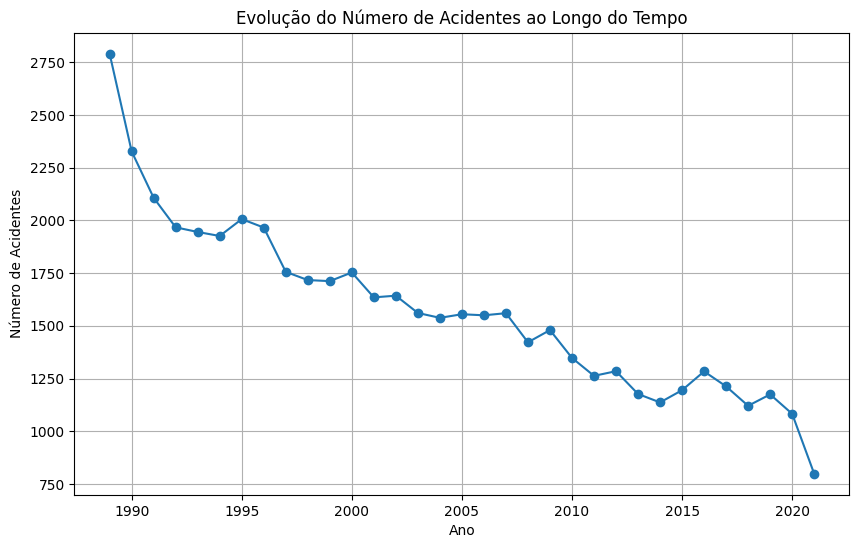

In [31]:
# acidentes por ano
acidente_ano = df.groupby('Ano')['ID'].count()
plt.figure(figsize=(10, 6))
plt.plot(acidente_ano.index, acidente_ano.values, marker='o')
plt.xlabel('Ano')
plt.ylabel('Número de Acidentes')
plt.title('Evolução do Número de Acidentes ao Longo do Tempo')
plt.grid(True)
plt.show()

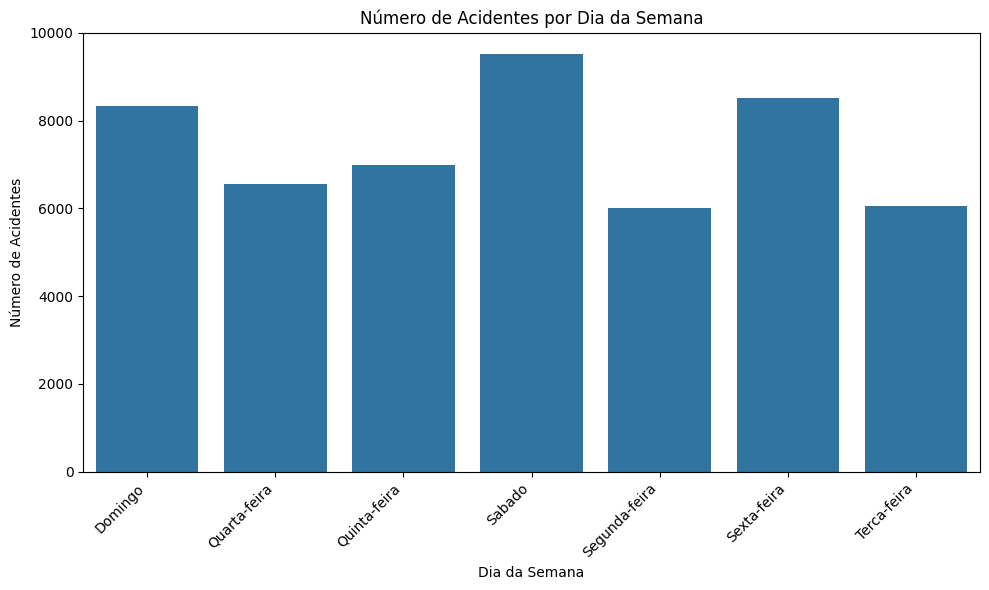

In [34]:
# Acidentes por dia da semana
acidentes_por_dia = df.groupby('Dia da Semana')['ID'].count()
plt.figure(figsize=(10, 6))
sns.barplot(x=acidentes_por_dia.index, y=acidentes_por_dia.values)
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Acidentes')
plt.title('Número de Acidentes por Dia da Semana')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


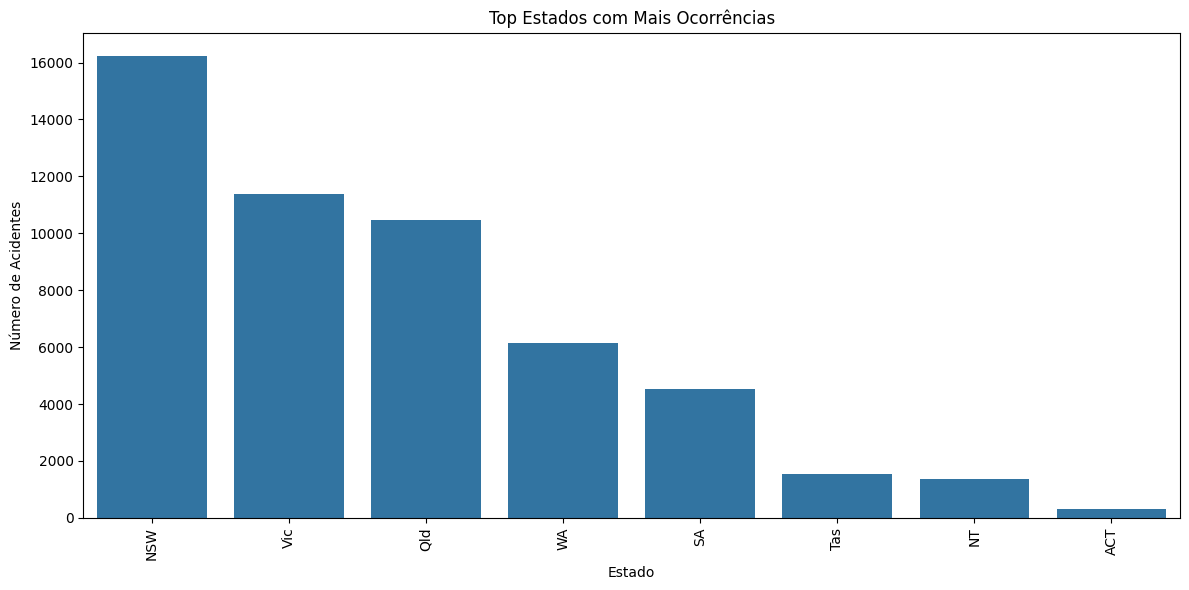

In [35]:
# Acidente por estado
acidentes_por_estado = df.groupby('Estado')['ID'].count()
acidentes_por_estado = acidentes_por_estado.sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=acidentes_por_estado.index, y=acidentes_por_estado.values)
plt.xlabel('Estado')
plt.ylabel('Número de Acidentes')
plt.title('Top Estados com Mais Ocorrências')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

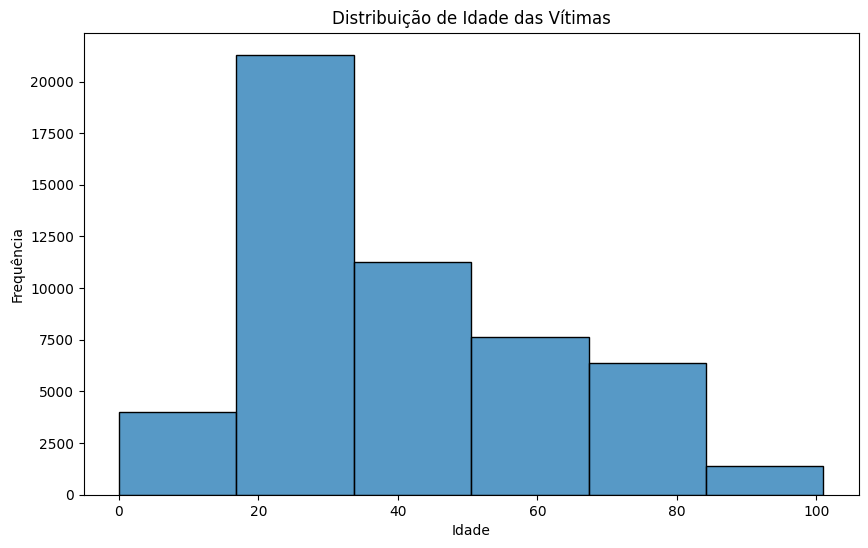

In [37]:
# Histograma de idade
plt.figure(figsize=(10, 6))
sns.histplot(df['Idade'], bins=6)
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Distribuição de Idade das Vítimas')
plt.show()

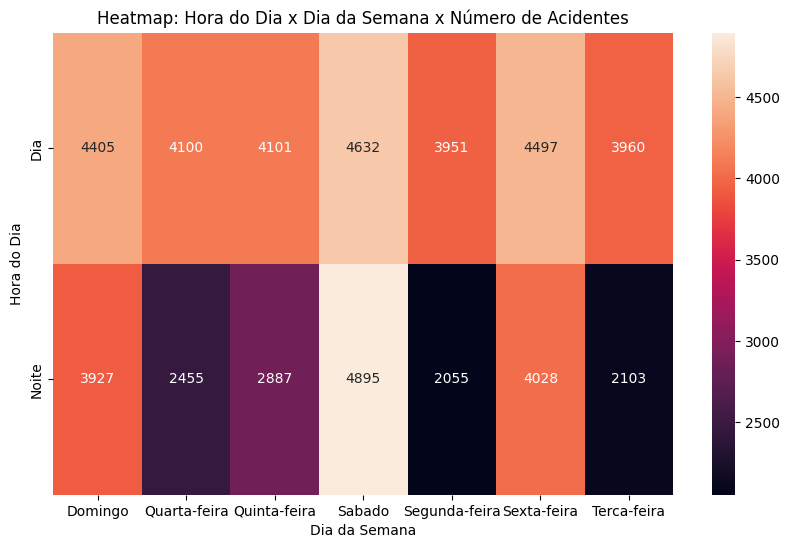

In [42]:
# mapa de calor da hora do dia por acidente

plt.figure(figsize=(10, 6))
heatmap_data = pd.pivot_table(df, values='ID', index='Hora do Dia', columns='Dia da Semana', aggfunc='count')
sns.heatmap(heatmap_data, annot=True, fmt="d")
plt.xlabel('Dia da Semana')
plt.ylabel('Hora do Dia')
plt.title('Heatmap: Hora do Dia x Dia da Semana x Número de Acidentes')
plt.show()

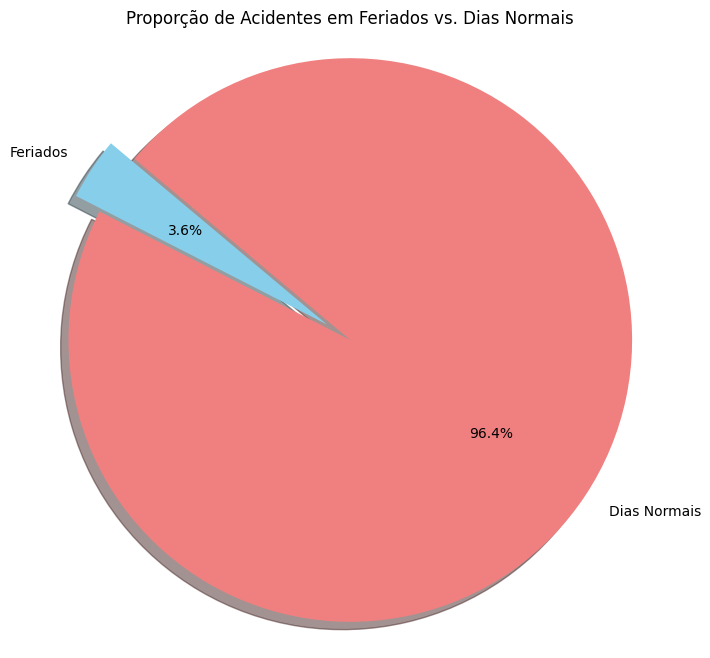

In [44]:
# Acidentes em feriados vs normais
Acidete_feriado = len(df[(df['Periodo de Natal'] == 'Sim') | (df['Periodo de Pascoa'] == 'Sim')])
Acidete_normal = len(df) - Acidete_feriado

labels = ['Feriados', 'Dias Normais']
sizes = [Acidete_feriado, Acidete_normal]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode the 1st slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Proporção de Acidentes em Feriados vs. Dias Normais')
plt.show()

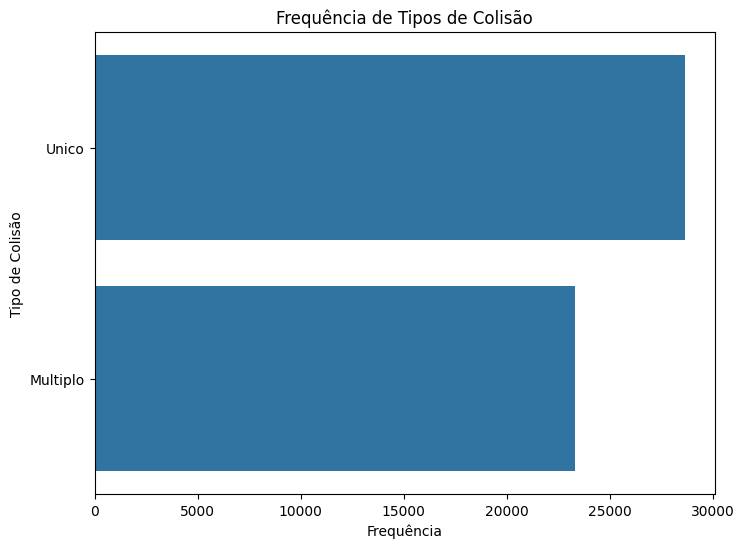

In [45]:
# Tipo de colisões
tipoColisao = df['Tipo de Acidente'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=tipoColisao.values, y=tipoColisao.index, orient='h')
plt.xlabel('Frequência')
plt.ylabel('Tipo de Colisão')
plt.title('Frequência de Tipos de Colisão')
plt.show()

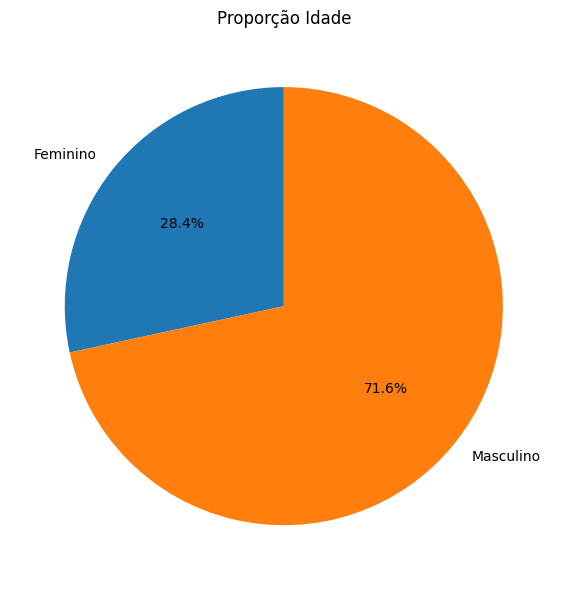

In [46]:
# Gráfico de pizza
plt.figure(figsize=(6,6))
df['Genero'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Proporção Idade')
plt.ylabel('')
plt.tight_layout()
plt.show()

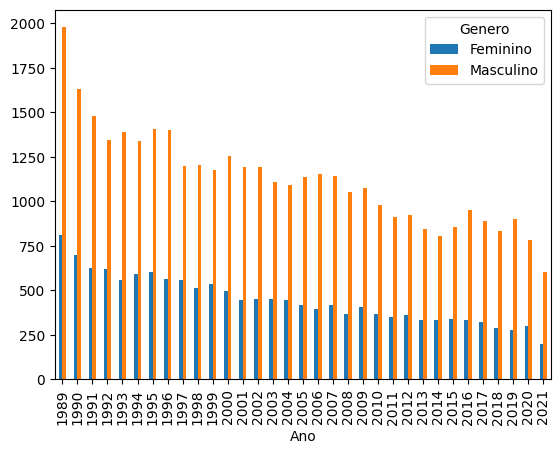

In [47]:
# Gráfico de barras agrupadas
pd.crosstab(df['Ano'], df['Genero']).plot(kind='bar')
plt.show()

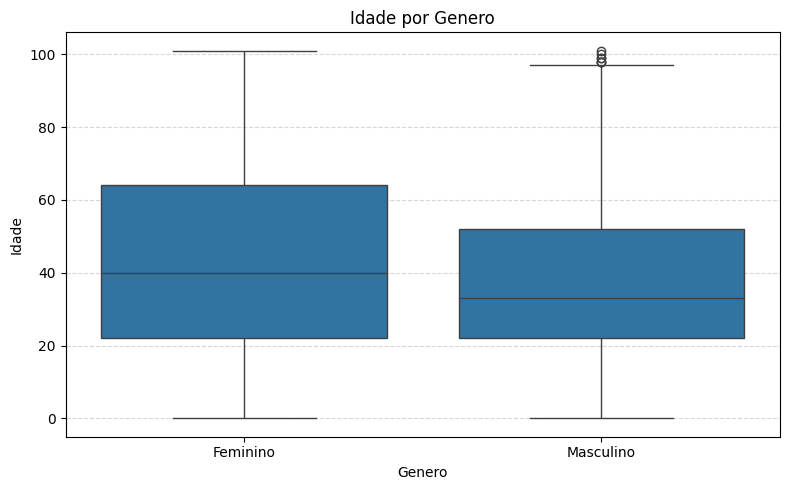

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Genero', y='Idade')
plt.title('Idade por Genero')
plt.xlabel('Genero')
plt.ylabel('Idade')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

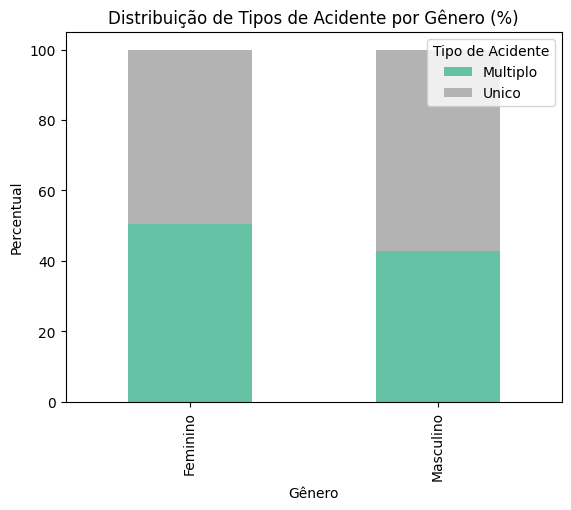

In [49]:
genero = df[df['Genero'].isin(['Masculino', 'Feminino'])]
genero_tipo = pd.crosstab(genero['Genero'], genero['Tipo de Acidente'], normalize='index') * 100
genero_tipo.plot(kind='bar', stacked=True, colormap="Set2", ax=plt.gca())
plt.title('Distribuição de Tipos de Acidente por Gênero (%)')
plt.ylabel('Percentual')
plt.xlabel('Gênero')
plt.legend(title='Tipo de Acidente')

<ipython-input-51-5170379c31c1>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contador_velocidade.index, y=contador_velocidade.values, palette="coolwarm", ax=plt.gca())


Text(0.5, 0, 'Categoria de Velocidade')

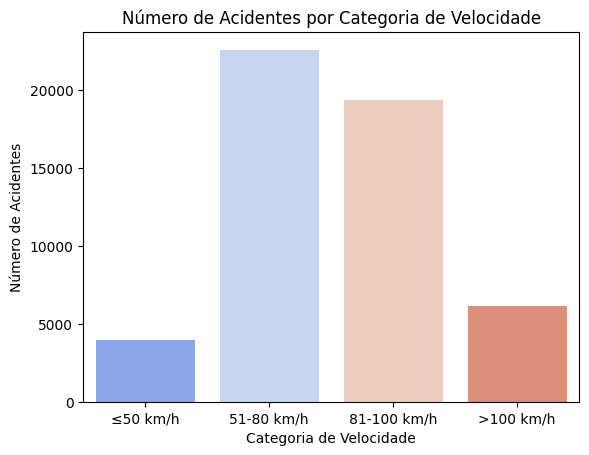

In [51]:
df['Limite de velocidade'] = pd.to_numeric(df['Limite de Velocidade'], errors='coerce')
# Categorizar velocidades
def velocidade(speed):
    if pd.isna(speed):
        return 'Unknown'
    elif speed <= 50:
        return '≤50 km/h'
    elif speed <= 80:
        return '51-80 km/h'
    elif speed <= 100:
        return '81-100 km/h'
    else:
        return '>100 km/h'

df['Categoria Velocidade'] = df['Limite de velocidade'].apply(velocidade)
contador_velocidade = df['Categoria Velocidade'].value_counts().reindex(['≤50 km/h', '51-80 km/h', '81-100 km/h', '>100 km/h'])
sns.barplot(x=contador_velocidade.index, y=contador_velocidade.values, palette="coolwarm", ax=plt.gca())
plt.title('Número de Acidentes por Categoria de Velocidade')
plt.ylabel('Número de Acidentes')
plt.xlabel('Categoria de Velocidade')

In [57]:
# probabilidade de um homem entre 17 a 25 anos de estar envolvido em um acidente
homem_17_25 = df[(df['Genero'] == 'Masculino') & (df['Idade'] >= 17) & (df['Idade'] <= 25)]


total_acidentes = len(df)
acidente_homem_17_25 = len(homem_17_25)
probablidade = acidente_homem_17_25 / total_acidentes if total_acidentes > 0 else 0

print(f"A probabilidade de um homem entre 17_25 anos estar envolvido em um acidente: {probablidade:.4f}")

A probabilidade de um homem entre 17_25 anos estar envolvido em um acidente: 0.2008


In [58]:
#Probabilidade de acidente com homem
df_genero = df[df['Genero'].isin(['Masculino', 'Feminino'])]
p_homem = (df_genero['Genero'] == 'Masculino').mean()
print(f'Probabilidade de acidente com homem: {p_homem:.2%}')

Probabilidade de acidente com homem: 71.61%


In [59]:
# Probabilidade de acidente em feriado
df['Feriado'] = df.apply(lambda row: 'Sim' if (row['Periodo de Natal'] == 'Sim' or row['Periodo de Pascoa'] == 'Sim') else 'Não', axis=1)
p_Feriado = (df['Feriado'] == 'Sim').mean()
print(f'Probabilidade de acidente em feriado: {p_Feriado:.2%}')

Probabilidade de acidente em feriado: 3.58%


In [60]:
# Probabilidade de acidente "Unico" com alta velocidade (>100 km/h)
df['Limite de Velocidade'] = pd.to_numeric(df['Limite de Velocidade'], errors='coerce')
velocidade_max = df[df['Limite de Velocidade'] > 100]
p_unico_altaVelociade = (velocidade_max['Tipo de Acidente'] == 'Unico').mean()
print(f'Probabilidade de acidente "Single" acima de 100km/h: {p_unico_altaVelociade:.2%}')

Probabilidade de acidente "Single" acima de 100km/h: 60.62%


In [54]:
tabela_conjunta = pd.crosstab(df['Genero'], df['Usuario de Rodovia'], margins=True)

print(tabela_conjunta)

Usuario de Rodovia  Ciclista  Garupa  Motociclista  Motorista  Other/-9  \
Genero                                                                    
Feminino                 192     199           236       5810        28   
Masculino               1211     159          6321      17695        44   
All                     1403     358          6557      23505        72   

Usuario de Rodovia  Passageiro  Pedestre    All  
Genero                                           
Feminino                  5695      2603  14763  
Masculino                 6292      5511  37233  
All                      11987      8114  51996  


In [61]:
# Hipótese: Gênero × Tipo de Acidente (Teste Qui-quadrado)
contingency_table = pd.crosstab(df_genero['Genero'], df_genero['Usuario de Rodovia'])
chi2, p_val, dof, ex = chi2_contingency(contingency_table)

print('\n[Hipótese 1] Gênero x Usuario de Rodoviae:')
print(f'Valor-p: {p_val:.5f}')
if p_val < 0.05:
    print('→ Rejeitamos H₀: Existe dependência entre Gênero e Usuario de Rodovia.')
else:
    print('→ Não rejeitamos H₀: Gênero e Usuario de Rodovia são independentes.')



[Hipótese 1] Gênero x Tipo de Acidente:
Valor-p: 0.00000
→ Rejeitamos H₀: Existe dependência entre Gênero e Tipo de Acidente.


In [65]:
# Hipótese: Acidentes em Feriados x Dias Normais (Teste de Proporções)
# Contar o número de acidentes em feriados e não feriados
count = np.array([
    df[df['Feriado'] == 'Sim'].shape[0],
    df[df['Feriado'] == 'Não'].shape[0]
])

# Número de dias de feriado e dias normais
# (Assumindo 14 dias de Natal + 4 dias de Páscoa ≈ 18 dias de feriado no ano)
# Se necessário, ajuste este valor conforme seu contexto
days_holiday = 18
days_normal = 365 - 18

z = np.array([days_holiday, days_normal])
z, p_valor = ztest(x1 = count, value = days_holiday, alternative='two-sided')

print('estatística z é igual a:', z)
print('p-valor é igual a:', p_valor)

print('\n[Hipótese 2] Acidentes em Feriados vs Dias Normais:')
print(f'Valor-p: {p_valor:.5f}')
if p_valor < 0.05:
    print('→ Rejeitamos H₀: A proporção de acidentes é diferente em feriados.')
else:
    print('→ Não rejeitamos H₀: A proporção de acidentes é similar entre feriados e dias normais.')

estatística z é igual a: 1.0762666224781474
p-valor é igual a: 0.2818080315857614

[Hipótese 2] Acidentes em Feriados vs Dias Normais:
Valor-p: 0.28181
→ Não rejeitamos H₀: A proporção de acidentes é similar entre feriados e dias normais.
